# The skill in demand for Data Analysts in New York

In [17]:
# Importing Libraries & Loading Data
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [ ]:
df_DA_NY = df[(df['job_title_short'] == 'Data Analyst') & (df['search_location'] == 'New York, United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_NY = df_DA_NY.dropna(subset=['salary_year_avg'])

df_DA_NY_exploded = df_DA_NY.explode('job_skills')

df_DA_NY_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
988,62623.0,sql
988,62623.0,excel
988,62623.0,tableau
3237,120000.0,sql
3237,120000.0,visio


## Calculate Percent of Job Postings that Have Skills

In [ ]:
df_DA_skills = df_DA_NY_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_NY) 

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

df_DA_skills = df_DA_skills[df_DA_skills['skill_count'] > 0]

df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,813,90000.0,54.308617
excel,647,85000.0,43.219773
python,509,95847.5,34.001336
tableau,493,90300.0,32.932532
r,355,90000.0,23.714095
...,...,...,...
jquery,1,122500.0,0.066800
selenium,1,82500.0,0.066800
splunk,1,145500.0,0.066800


## Median Salary & Percent Skill Demand

In [20]:
skill_limit = 20

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_limit]

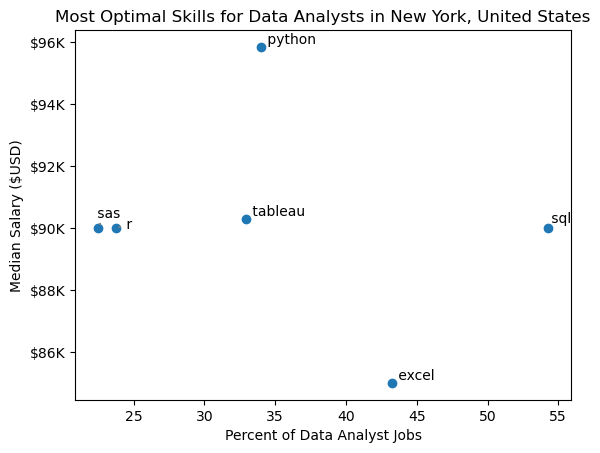

In [21]:
from adjustText import adjust_text

plt.scatter(df_DA_skills_high_demand['skill_percent'], df_DA_skills_high_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  
plt.title('Most Optimal Skills for Data Analysts in New York, United States')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')) 


texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], " " + txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()